In [11]:
import mplfinance as mpf
import kagglehub
import pandas as pd
import os
import numpy as np

Download data

In [12]:
# Download latest version
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\adria\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\726


Load data

In [13]:
csv_path = os.path.join(path, "btcusd_1-min_data.csv")
df = pd.read_csv(csv_path)

df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


Data analysis

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7738683 entries, 0 to 7738682
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 354.2 MB


In [15]:
df.isnull().sum()

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

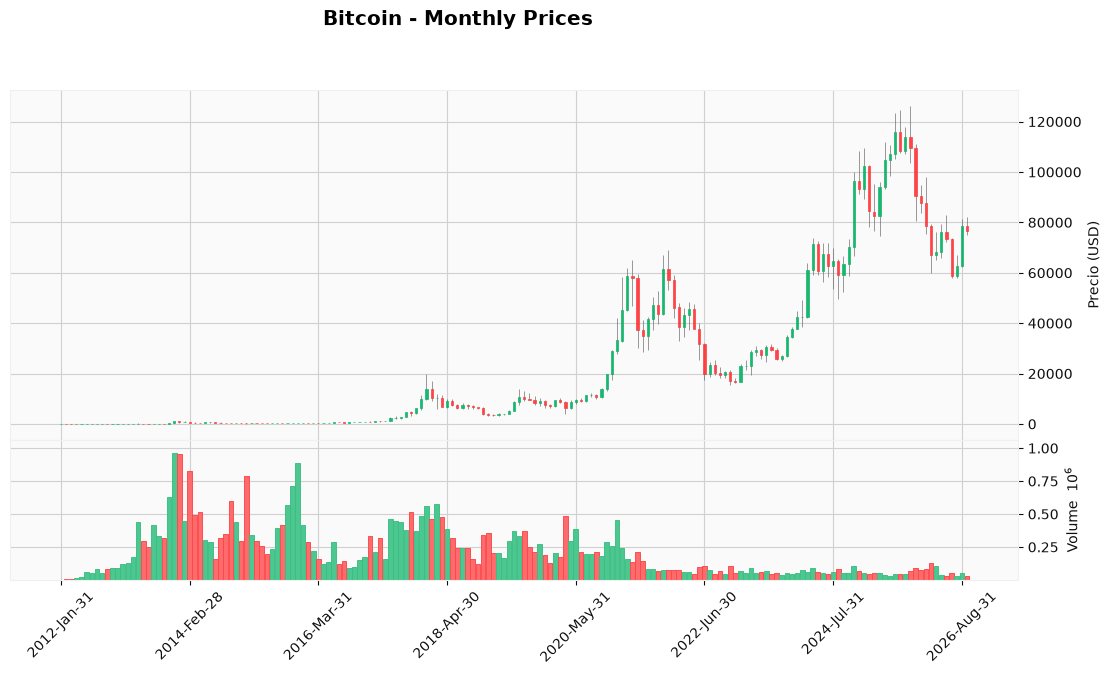

In [16]:

# Convert timestamp Unix to datetime and use it as index for resampling
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('Timestamp')

df_monthly = df.copy()
# Resampling from 1 minute to monthly
df_monthly = df_monthly.resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

# Candle graph of monthly Bitcoin prices
mpf.plot(
    df_monthly,
    type='candle',
    style='yahoo',
    title='Bitcoin - Monthly Prices',
    ylabel='Precio (USD)',
    volume=True,
    figsize=(14, 7)
)

Bitcoin's Monthly Price Evolution (2012–2026)

The chart shows Bitcoin's monthly candlesticks from its early days in 2012 to the present, with trading volume displayed below. Several distinct market cycles stand out: a barely visible growth phase until 2016 (when the price moved in a range of a few dollars to a few hundred), followed by the first major speculative bubble in late 2017, which pushed the price to highs near $20,000 before a prolonged decline.

Starting in 2020, the asset entered a new bull cycle driven by institutional adoption, reaching new all-time highs in 2021. After a correction in 2022, the price resumed its upward trend from 2023 onward, surpassing $100,000 at the most recent peak visible in the chart, followed by a consolidation/correction phase around $75,000–$80,000.

As for volume, the highest peaks (in relative terms) are concentrated in the earlier years, when the market was much smaller and proportionally more volatile, while in the more recent cycles monthly volume — though larger in absolute terms — appears more compressed on the chart's scale due to the overall growth of the market.

### Our first aproach

Looking at the data and resources availables we have decided that we'll aproach the problem trying to predict relative changes in price instead of the absolute future values. Our objective we'll be to predict the hourly relative change for the next day looking at the aggregated hourly data from the previous week.

We belive that this information can be more usefull and easier to calculate with more presicion than the exact values, given the inmense range in values of the data.

In [17]:
#Hourly data aggregation

df_hourly = df.copy()
# Resampling from 1 minute to hourly
df_hourly = df_hourly.resample('h').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

df_hourly.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 01:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 02:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 03:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 04:00:00,4.58,4.58,4.58,4.58,1.502


In [18]:
# Real porcentual change calculation
df_hourly['Return'] = df_hourly['Close'].pct_change()
df_hourly = df_hourly.dropna()

In [19]:
# Generate all posible time windows for the model
INPUT_HOURS = 168 
TARGET_HOURS = 24

feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return']
target_col = 'Return'

data = df_hourly[feature_cols].values
returns = df_hourly[target_col].values
timestamps = df_hourly.index

n_samples = len(df_hourly) - INPUT_HOURS - TARGET_HOURS + 1

X = np.zeros((n_samples, INPUT_HOURS, len(feature_cols)))
y = np.zeros((n_samples, TARGET_HOURS))
sample_end_dates = []  

for i in range(n_samples):
    X[i] = data[i : i + INPUT_HOURS]
    y[i] = returns[i + INPUT_HOURS : i + INPUT_HOURS + TARGET_HOURS]
    sample_end_dates.append(timestamps[i + INPUT_HOURS + TARGET_HOURS - 1])

sample_end_dates = pd.to_datetime(sample_end_dates)

print(f"Total samples generated: {n_samples}")
print(f"Shape of X: {X.shape}")  # (n_samples, 168, n_features)
print(f"Shape of y: {y.shape}")  # (n_samples, 24)

Total samples generated: 128787
Shape of X: (128787, 168, 6)
Shape of y: (128787, 24)


In [22]:
# Train and test split, keeping the temporal order of the samples to prevent data leakage. The first 80% of the samples will be used for training, and the last 20% for testing.

split_ratio = 0.8
split_idx = int(n_samples * split_ratio)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = sample_end_dates[:split_idx], sample_end_dates[split_idx:]

print(f"Train: {X_train.shape[0]} samples ({dates_train[0]} -> {dates_train[-1]})")
print(f"Test:  {X_test.shape[0]} samples ({dates_test[0]} -> {dates_test[-1]})")

Train: 103029 samples (2012-01-09 00:00:00 -> 2023-10-10 20:00:00)
Test:  25758 samples (2023-10-10 21:00:00 -> 2026-09-18 02:00:00)


This is the basic training and test data, further data preparation can be done in the future depending on the models tested